<a href="https://colab.research.google.com/github/luciano328/everpeak-analysis/blob/main/S7_Version_Estudiante_Project_ConnectaTel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel.

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


---
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [ ]:
plans.head()

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [ ]:
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [ ]:
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [ ]:
print("plans:", plans.shape)
print("users:", users.shape)
print("usage:", usage.shape)

plans: (2, 8)
users: (4000, 8)
usage: (40000, 6)


In [ ]:
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [ ]:
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [ ]:
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [ ]:
# cantidad de nulos para users

print("Cantidad de valores nulos:")
print(users.isna().sum())

print("\nProporción de valores nulos:")
print((users.isna().mean() * 100).round(2))

Cantidad de valores nulos:
user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64

Proporción de valores nulos:
user_id        0.00
first_name     0.00
last_name      0.00
age            0.00
city          11.72
reg_date       0.00
plan           0.00
churn_date    88.35
dtype: float64


In [ ]:
# cantidad de nulos para usage

print("Cantidad de valores nulos:")
print(usage.isna().sum())

print("\nProporción de valores nulos:")
print((usage.isna().mean() * 100).round(2))

Cantidad de valores nulos:
id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64

Proporción de valores nulos:
id           0.00
user_id      0.00
type         0.00
date         0.12
duration    55.19
length      44.74
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos.

 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?


COMENTARIO

El dataset users presenta valores nulos en city (11.72%), por lo que requiere revisión para decidir si conviene imputarlos o mantenerlos como nulos.
La columna churn_date tiene 88.35% de valores faltantes, pero antes de eliminarla es necesario verificar si esos nulos representan clientes que aún no han cancelado el servicio.
En usage, las columnas duration (55.19%) y length (44.74%) presentan muchos valores faltantes, aunque primero se debe investigar si estos dependen del tipo de registro (call o text).
Por ultimo, la columna date solo presenta un 0.12% de nulos y probablemente podrá tratarse fácilmente.


### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [ ]:
users.describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna user_id contiene identificadores únicos consecutivos y no presenta valores inválidos.
- La columna age presenta un valor mínimo de -999, el cual es imposible para una edad y corresponde a un valor centinela que deberá corregirse.

In [ ]:
usage.describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas id y user_id corresponden a identificadores únicos y no presentan valores inválidos
- Las columnas duration y length no presentan valores negativos ni sentinels. Se observan valores mínimos de 0, los cuales podrían ser válidos dependiendo del tipo de registro, por lo que se analizarán en las siguientes etapas

In [ ]:
# explorar columnas categóricas de users

columnas_user = ['city', 'plan']

for col in columnas_user:
    print(f"\n===== {col} =====")
    print(users[col].value_counts(dropna=False))


===== city =====
Bogotá      808
CDMX        730
Medellín    616
NaN         469
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64

===== plan =====
Basico     2595
Premium    1405
Name: plan, dtype: int64


- La columna city contiene ciudades válidas, pero también presenta el valor "?", el cual corresponde a un valor centinela y deberá reemplazarse por un valor nulo (pd.NA) durante la limpieza de datos. Además, existen valores faltantes (NaN) que deberán evaluarse posteriormente.
- La columna plan solo contiene las categorías esperadas (basico y premium) y no presenta valores inválidos.

In [ ]:
usage["type"].value_counts(dropna=False)

text    22092
call    17908
Name: type, dtype: int64

- La columna type solo contiene las categorias esperadas (call y text) y no representan valores invalidos.

---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso.

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?  
- ¿Qué acción tomarías?  

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [ ]:
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')

In [ ]:
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')

In [ ]:
users['reg_date'].dt.year.value_counts().sort_index()


2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64

- En reg_date aparecen registros de los años 2022, 2023 y 2024, que son validos para el analisis. Sin embargo, existen 40 registros con fecha en 2026, lo cual corresponde a fechas futuras e indica un error de captura. Estas fechas deberán marcarse como valores nulos durante la limpieza de datos.

In [ ]:
usage['date'].dt.year.value_counts().sort_index()

2024.0    39950
Name: date, dtype: int64

- La columna date solo contiene registros correspondientes al año 2024, por lo que no se detectan fechas fuera del rango esperado. Esta columna puede utilizarse con confianza para el análisis.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- ¿Qué harías con ellas?

COMENTARIO

En conclusión, en la columna reg_date se detectaron 40 registros con fechas del año 2026, lo que corresponde a fechas futuras y representa un error de captura. Estas fechas deberán marcarse como valores nulos (NaT) durante la limpieza de datos.
En cambio, la columna date del dataset usage solo contiene registros del año 2024, por lo que no presenta problemas y puede utilizarse para el análisis.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [ ]:
# Reemplazar -999 por la mediana de age

age_mediana = users.loc[users['age'] != -999, 'age'].median()

users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [ ]:
# Reemplazar ? por NA en city

users['city'] = users['city'].replace('?', pd.NA)

# Verificar cambios
users['city'].value_counts(dropna=False)

Bogotá      808
CDMX        730
Medellín    616
NaN         565
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64

In [ ]:
# Marcar fechas futuras como NA para reg_date

users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = pd.NaT

# Verificar cambios
users['reg_date'].dt.year.value_counts(dropna=False).sort_index()

2022.0    1314
2023.0    1316
2024.0    1330
NaN         40
Name: reg_date, dtype: int64

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [ ]:
pd.crosstab(
    usage['type'],
    usage['duration'].isna(),
    margins=True
)

duration,False,True,All
type,,,
call,17908,0,17908
text,16,22076,22092
All,17924,22076,40000


In [ ]:
pd.crosstab(
    usage['type'],
    usage['length'].isna(),
    margins=True
)

length,False,True,All
type,,,
call,12,17896,17908
text,22092,0,22092
All,22104,17896,40000


- Los valores nulos de duration y length dependen del tipo de registro (type).
- Las llamadas (call) tienen duración pero normalmente no tienen longitud (length), mientras que los mensajes (text) tienen longitud pero no duración (duration). Por ello, estos valores nulos son esperados por la naturaleza de los datos y se conservarán como NaN, ya que imputarlos podría introducir información incorrecta en el análisis.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico.

**Instrucciones:**:
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [ ]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int)
usage["is_call"] = (usage["type"] == "call").astype(int)

# Agrupar información por usuario
usage_agg = (
    usage.groupby("user_id")
    .agg({
        "is_text": "sum",
        "is_call": "sum",
        "duration": "sum"
    })
    .reset_index()
)

# Observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={
    "is_text": "cant_mensajes",
    "is_call": "cant_llamadas",
    "duration": "cant_minutos_llamada"
})

# Observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:
# Combinar la tabla agregada con el dataset de usuarios

user_profile = users.merge(
    usage_agg,
    on="user_id",
    how="left"
)

# Observar resultado
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [ ]:
# Resumen estadístico de las columnas numéricas

user_profile[
    [
        "age",
        "cant_mensajes",
        "cant_llamadas",
        "cant_minutos_llamada"
    ]
].describe()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.136000,5.524381,4.478120,23.317054
std,17.689919,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,48.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


In [ ]:
# Distribución porcentual del tipo de plan

(user_profile["plan"]
 .value_counts(normalize=True) * 100
).round(2)

Basico     64.88
Premium    35.12
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada`

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda)

**Hint**  
Para cada histograma,
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

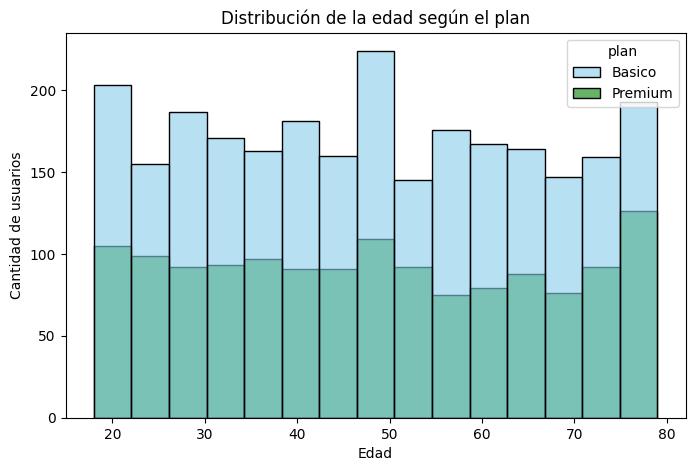

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=user_profile,
    x="age",
    hue="plan",
    bins=15,
    palette=["skyblue", "green"],
    alpha=0.6
)

plt.title("Distribución de la edad según el plan")
plt.xlabel("Edad")
plt.ylabel("Cantidad de usuarios")

plt.show()

- La distribución de edades es relativamente uniforme entre los 18 y 79 años.
- El plan Básico concentra una mayor cantidad de usuarios en casi todos los rangos de edad debido a que representa la mayor parte de la base de clientes.
- No se observa un patrón claro que indique que un grupo de edad en específico prefiera un plan sobre otro.

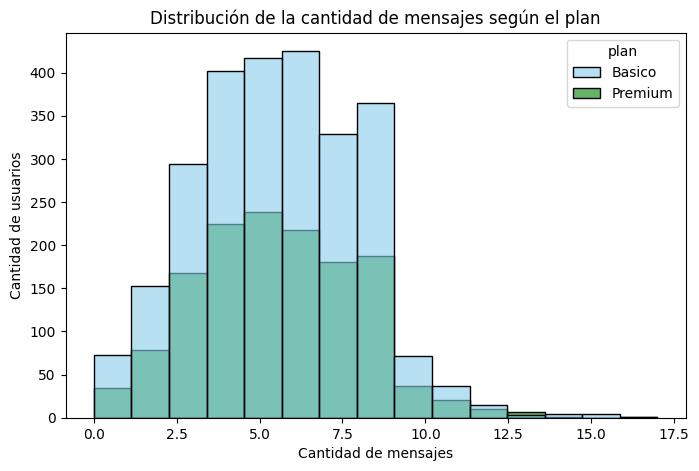

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=user_profile,
    x="cant_mensajes",
    hue="plan",
    bins=15,
    palette=["skyblue", "green"],
    alpha=0.6
)

plt.title("Distribución de la cantidad de mensajes según el plan")
plt.xlabel("Cantidad de mensajes")
plt.ylabel("Cantidad de usuarios")

plt.show()

- La mayoría de los usuarios envía entre 3 y 8 mensajes. La distribución presenta una ligera asimetría hacia la derecha debido a que existen pocos usuarios con una cantidad alta de mensajes.
- Ambos planes muestran un comportamiento similar, aunque el plan basico concentra mas usuarios por representar la mayor parte de la cartera de clientes.

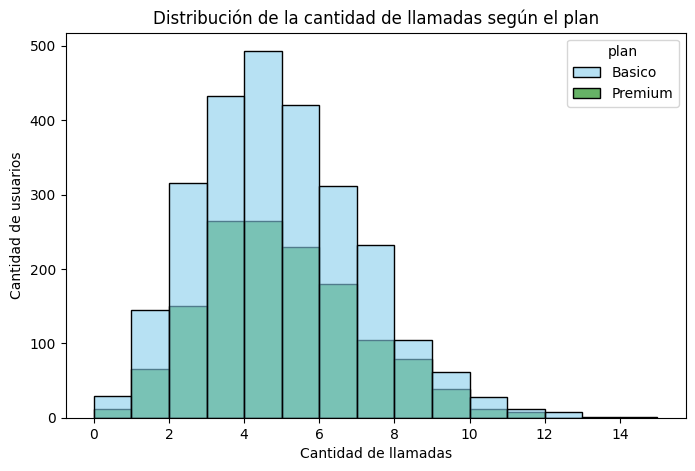

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=user_profile,
    x="cant_llamadas",
    hue="plan",
    bins=15,
    palette=["skyblue", "green"],
    alpha=0.6
)

plt.title("Distribución de la cantidad de llamadas según el plan")
plt.xlabel("Cantidad de llamadas")
plt.ylabel("Cantidad de usuarios")

plt.show()

- La mayoría de los usuarios realiza entre 3 y 6 llamadas.
- La distribucion presenta una ligera asimetría hacia la derecha, ya que existe un pequeño grupo de usuarios con una cantidad elevada en llamadas.
- Por ultimo, ambos planes muestran un comportamiento similar, aunque el plan basico concentra más usuarios debido a su mayor participación en la cartera de clientes.

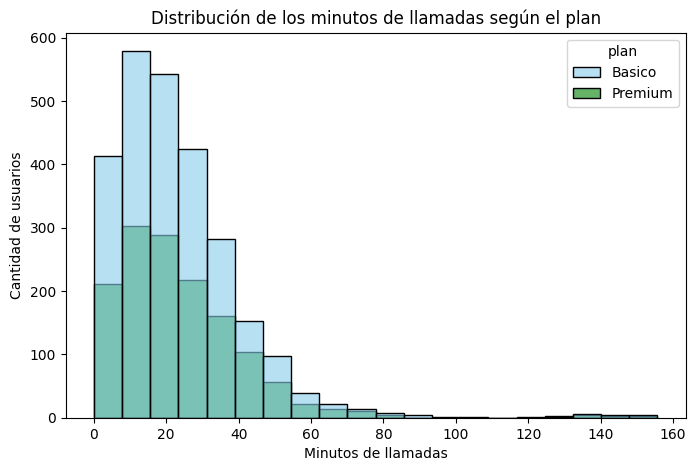

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=user_profile,
    x="cant_minutos_llamada",
    hue="plan",
    bins=20,
    palette=["skyblue", "green"],
    alpha=0.6
)

plt.title("Distribución de los minutos de llamadas según el plan")
plt.xlabel("Minutos de llamadas")
plt.ylabel("Cantidad de usuarios")

plt.show()

- La mayoría de los usuarios acumula entre 5 y 30 minutos de llamadas.
- La distribución esta sesgada hacia la derecha, con algunos usuarios que presentan consumos mucho mas altos que el resto.
- El comportamiento entre ambos planes es similar, aunque el plan Básico concentra una mayor cantidad de usuarios.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age`
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

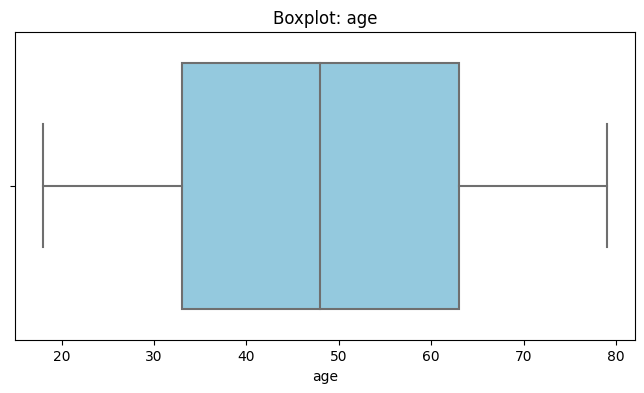

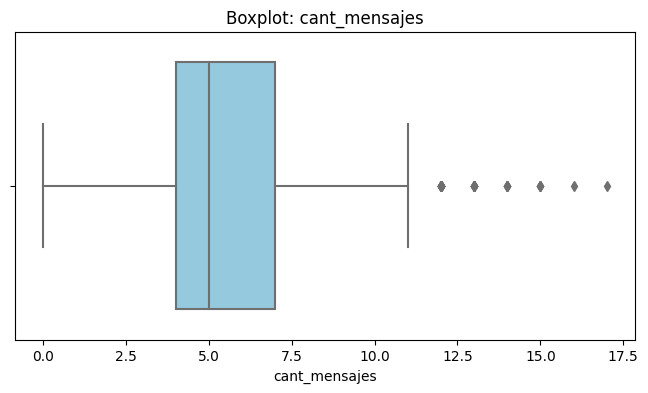

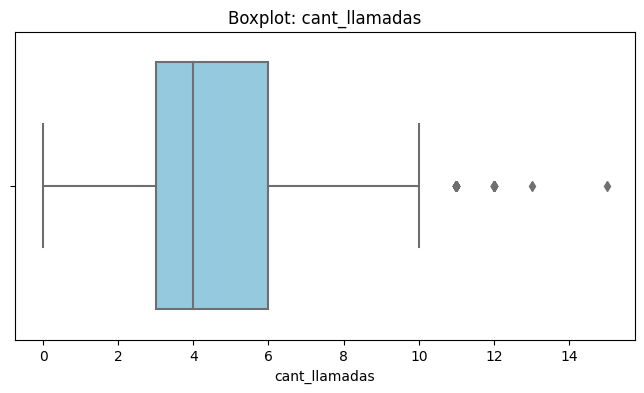

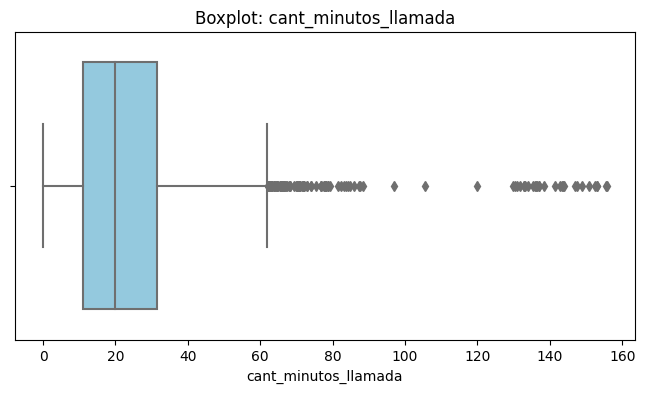

In [ ]:
# Visualizando usando BoxPlot

columnas_numericas = ["age", "cant_mensajes", "cant_llamadas", "cant_minutos_llamada"]

for col in columnas_numericas:
    plt.figure(figsize=(8,4))

    sns.boxplot(
        x=user_profile[col],
        color="skyblue"
    )

    plt.title(f"Boxplot: {col}")
    plt.xlabel(col)
    plt.show()

💡 Insights:

- Age: No presenta outliers visibles. La distribución de edades se encuentra dentro de un rango esperado.
- cant_mensajes: Presenta algunos outliers superiores (usuarios que envían muchos más mensajes que el resto).
- cant_llamadas: Presenta algunos outliers superiores correspondientes a usuarios con una cantidad de llamadas mayor al comportamiento habitual.
- cant_minutos_llamada: Presenta una gran cantidad de outliers superiores debido a usuarios con un consumo muy elevado de minutos de llamada.

In [ ]:
# Calcular límites con el método IQR

columnas_limites = ["cant_mensajes", "cant_llamadas", "cant_minutos_llamada"]

for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1

    limite_superior = Q3 + 1.5 * IQR

    print(f"\n{col}")
    print(f"Límite superior: {limite_superior:.2f}")
    print(f"Valor máximo: {user_profile[col].max():.2f}")


cant_mensajes
Límite superior: 11.50
Valor máximo: 17.00

cant_llamadas
Límite superior: 10.50
Valor máximo: 15.00

cant_minutos_llamada
Límite superior: 61.86
Valor máximo: 155.69


In [ ]:
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡 Insights:

- cant_mensajes: Se observan valores superiores al límite IQR. Se recomienda mantener los outliers porque representan usuarios con un uso intensivo de mensajes y aportan información relevante para el analisis.
- cant_llamadas: Existen outliers por encima del límite superior. Se mantienen debido a que corresponden a clientes con un patrón real de alto uso.
- cant_minutos_llamada: Presenta una gran cantidad de outliers superiores. Se recomienda conservarlos porque reflejan clientes con un consumo elevado de minutos.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [ ]:
# Crear columna grupo_uso

user_profile["grupo_uso"] = "Alto uso"

user_profile.loc[
    (user_profile["cant_llamadas"] < 5) &
    (user_profile["cant_mensajes"] < 5),
    "grupo_uso"
] = "Bajo uso"

user_profile.loc[
    (user_profile["cant_llamadas"] < 10) &
    (user_profile["cant_mensajes"] < 10) &
    (user_profile["grupo_uso"] != "Bajo uso"),
    "grupo_uso"
] = "Uso medio"

In [ ]:
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [ ]:
# Crear columna grupo_edad

user_profile["grupo_edad"] = "Adulto Mayor"

user_profile.loc[
    user_profile["age"] < 30,
    "grupo_edad"
] = "Joven"

user_profile.loc[
    (user_profile["age"] >= 30) &
    (user_profile["age"] < 60),
    "grupo_edad"
] = "Adulto"

In [ ]:
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

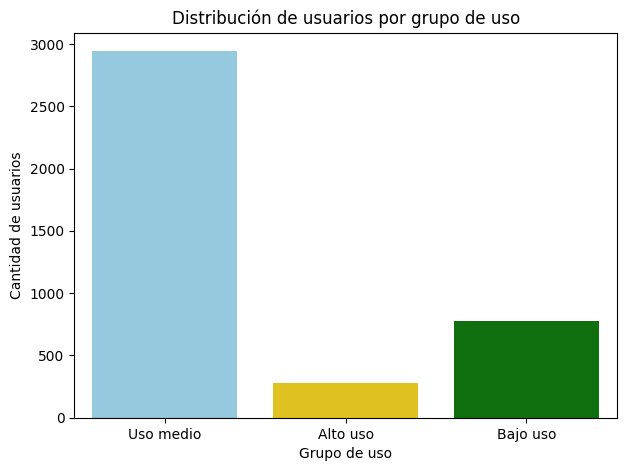

In [ ]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=user_profile,
    x="grupo_uso",
    palette=["skyblue","gold","green"]
)

plt.title("Distribución de usuarios por grupo de uso")
plt.xlabel("Grupo de uso")
plt.ylabel("Cantidad de usuarios")

plt.show()

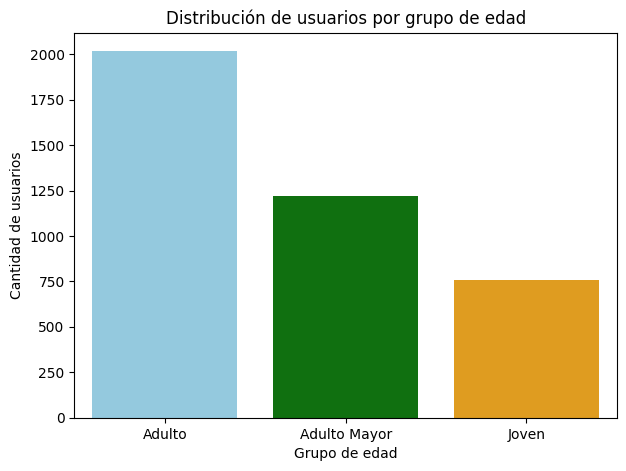

In [ ]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=user_profile,
    x="grupo_edad",
    palette=["skyblue","green","orange"]
)

plt.title("Distribución de usuarios por grupo de edad")
plt.xlabel("Grupo de edad")
plt.ylabel("Cantidad de usuarios")

plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:**
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- Se detectaron valores faltantes en la columna city (469 registros, 11,72%), los cuales fueron convertidos a valores nulos para evitar inconsistencias.
- La columna churn_date presentó un 88,35% de valores nulos, pero estos corresponden a clientes que continúan activos, por lo que se decidió mantenerlos.
  Ademas, se identificaron edades con el valor sentinela -999, ciudades registradas como "?" y fechas de registro futuras (año 2026), las cuales fueron corregidas durante la limpieza de datos

🔍 **Segmentos por Edad**
- El segmento con mayor cantidad de clientes corresponde a Adultos (30–59 años), seguido por Adultos Mayores (60 años o más). El grupo de Jovenes (<30 años) es el menos representado.
- En consecuencia, la base de clientes de ConectaTel esta compuesta principalmente por usuarios adultos, quienes representan el principal mercado objetivo de la empresa

📊 **Segmentos por Nivel de Uso**
- La mayoría de los clientes pertenece al segmento de uso medio, mientras que una menor proporción corresponde a usuarios de bajo uso y un grupo reducido presenta Alto uso.
- Los usuarios de alto consumo representan una oportunidad importante para estrategias de fidelizacion y planes Premium, ya que generan un mayor uso de los servicios


➡️ Esto sugiere que a mayor parte de los clientes mantiene un comportamiento de consumo estable, mientras que existe un grupo reducido de usuarios intensivos que podría aportar mayor rentabilidad mediante ofertas y planes personalizados


💡 **Recomendaciones**
- Diseñar campañas comerciales dirigidas a los usuarios de Uso medio, incentivándolos a migrar hacia planes Premium mediante beneficios adicionales o mayores capacidades de llamadas y mensajes.
- Mantener el seguimiento de los usuarios con consumo muy elevado (outliers), ya que representan clientes reales cuyo comportamiento puede servir para optimizar la oferta de productos y mejorar las estrategias de segmentación.

* Por ultimo, mencionar que los outliers no fueron eliminados porque representan clientes reales de alto consumo. Ademas, la mayoría de los usuarios pertenece al plan Básico (64,88%), por lo que existe potencial para campañas de migración al plan Premium (35,12%)

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`